In [1]:
import numpy as np
import pandas as pd
pd.options.mode.chained_assignment = None  # default='warn'
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

### Pull the csv files for success metric and binarized mechanics and categories

In [2]:
game_success = pd.read_csv('data/data_sources_gold/game_success_metrics.csv').iloc[:,1:]

In [3]:
mechanics_binary = pd.read_csv('data/data_sources_silver/game_mechanics_binary.csv').iloc[:,1:]
categories_binary = pd.read_csv('data/data_sources_silver/game_categories_binary.csv').iloc[:,1:]

In [4]:
# rename binary columns for clarity
rename_mechanics = dict((col, f'{col}_mechanic')for col in mechanics_binary.drop(columns='id').columns)
rename_categories = dict((col, f'{col}_category') for col in categories_binary.drop(columns='id').columns)

mechanics_binary = mechanics_binary.rename(columns=rename_mechanics)
categories_binary = categories_binary.rename(columns=rename_categories)

In [5]:
# get rid of games with 0 success score

game_success = game_success[game_success['success_score'] > 0]
mechanics_binary = mechanics_binary[mechanics_binary['id'].isin(game_success['id'])]
categories_binary = categories_binary[categories_binary['id'].isin(game_success['id'])]

len(game_success), len(mechanics_binary), len(categories_binary)

(39295, 39295, 39295)

In [6]:
# set the order of most commonly used mechanics and categories

ordered_mechanics = mechanics_binary.iloc[:,1:].sum().sort_values(ascending=False).index
ordered_categories = categories_binary.iloc[:,1:].sum().sort_values(ascending=False).index

## First find out how many mechanics and categories we should include

Iterate through the list of mechanics and categories ordered by most common. Find the indices of all games, add new unique games to a list keeping track of all the games as they appear. Record the cumulative count and percentage of total games.

In [7]:
mechanic_ordered_count = pd.DataFrame(columns=['top_n_mechanics', 'mechanic', 'games', 'cumulative_count', 'cumulative_pct'])
track_games = set()
top_n_mechanics = 1

for mechanic in ordered_mechanics:
    relevant_games = set(mechanics_binary[mechanics_binary[mechanic] == 1]['id'])
    track_games = track_games | relevant_games
    new_row = pd.DataFrame([[top_n_mechanics, mechanic, track_games, len(track_games), len(track_games) / len(game_success)]], columns=mechanic_ordered_count.columns)
    mechanic_ordered_count = pd.concat([mechanic_ordered_count, new_row])
    top_n_mechanics += 1

category_ordered_count = pd.DataFrame(columns=['top_n_categories', 'category', 'games', 'cumulative_count', 'cumulative_pct'])
track_games = set()
top_n_categories = 1

for category in ordered_categories:
    relevant_games = set(categories_binary[categories_binary[category] == 1]['id'])
    track_games = track_games | relevant_games
    new_row = pd.DataFrame([[top_n_categories, category, track_games, len(track_games), len(track_games) / len(game_success)]], columns=category_ordered_count.columns)
    category_ordered_count = pd.concat([category_ordered_count, new_row])
    top_n_categories += 1

/tmp/ipykernel_913/1064165956.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  mechanic_ordered_count = pd.concat([mechanic_ordered_count, new_row])
/tmp/ipykernel_913/1064165956.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  category_ordered_count = pd.concat([category_ordered_count, new_row])


In [8]:
mechanic_ordered_count.head()

,top_n_mechanics,mechanic,games,cumulative_count,cumulative_pct
0,1,Dice Rolling_mechanic,"{1, 65540, 6, 360457, 98315, 13, 262158, 17, 2...",10293,0.261942
0,2,Hand Management_mechanic,"{1, 3, 65540, 5, 6, 360455, 360457, 10, 98315,...",16098,0.409670
0,3,Set Collection_mechanic,"{1, 3, 65540, 5, 6, 4, 10, 11, 12, 13, 262158,...",19076,0.485456
0,4,Hexagon Grid_mechanic,"{1, 3, 65540, 5, 6, 4, 10, 11, 12, 13, 262158,...",20690,0.526530
0,5,Variable Player Powers_mechanic,"{1, 3, 65540, 5, 6, 4, 10, 11, 12, 13, 262158,...",21792,0.554574


### Of the games that appear in both the top $n$ mechanics and categories, how many total games are there and what percentage of all games do they represent?

In [9]:
#limiting the number of mechanics/categories due to compute limitations in deepnote,
# this should 
top_n = 28

explode_mechanics = mechanic_ordered_count[['top_n_mechanics', 'games']].iloc[:top_n].explode('games')
explode_categories = category_ordered_count[['top_n_categories', 'games']].iloc[:top_n].explode('games')

mech_cat_intersect_count = (
    explode_mechanics.merge(explode_categories, on='games')
     .groupby(['top_n_mechanics', 'top_n_categories'])
     .size()
     .unstack(fill_value=0)
)

In [10]:
mech_cat_intersect_pct = mech_cat_intersect_count / len(game_success)
mech_cat_intersect_pct.head()

top_n_categories,1,2,3,4,5,6,7,8,9,10,...,19,20,21,22,23,24,25,26,27,28
top_n_mechanics,,,,,,,,,,,,,,,,,,,,,
1,0.026874,0.132918,0.157628,0.163914,0.178216,0.215422,0.217839,0.219926,0.227688,0.232701,...,0.244433,0.245298,0.246520,0.246800,0.247538,0.248225,0.249981,0.250210,0.250973,0.251381
2,0.130933,0.239496,0.270951,0.278916,0.294872,0.332409,0.337778,0.342893,0.353582,0.362005,...,0.379107,0.381117,0.383026,0.383560,0.384884,0.385622,0.388599,0.388930,0.389973,0.390686
3,0.161140,0.269831,0.306146,0.316223,0.337626,0.375824,0.384680,0.392391,0.404810,0.424202,...,0.444331,0.447080,0.449854,0.450999,0.453238,0.454256,0.457285,0.457997,0.459193,0.460262
4,0.161445,0.303346,0.340807,0.350935,0.372592,0.410816,0.420588,0.429673,0.442881,0.463596,...,0.484133,0.487187,0.489986,0.491386,0.493727,0.494745,0.497799,0.498511,0.499707,0.500802
5,0.169487,0.313271,0.355363,0.366484,0.388548,0.427179,0.437791,0.447665,0.463647,0.485660,...,0.509123,0.512381,0.515282,0.516860,0.519354,0.520372,0.523654,0.524494,0.525843,0.526963


In [11]:
mech_cat_diag = pd.DataFrame(index=mech_cat_intersect_count.index, data=np.diag(mech_cat_intersect_count))
mech_cat_diag = mech_cat_diag.reset_index().rename(columns={'top_n_mechanics': 'n', 0: 'count'})

diag_pct = mech_cat_diag.copy()
diag_pct['count'] = diag_pct['count'] / len(game_success)
diag_pct = diag_pct.rename(columns={'count': 'pct'})

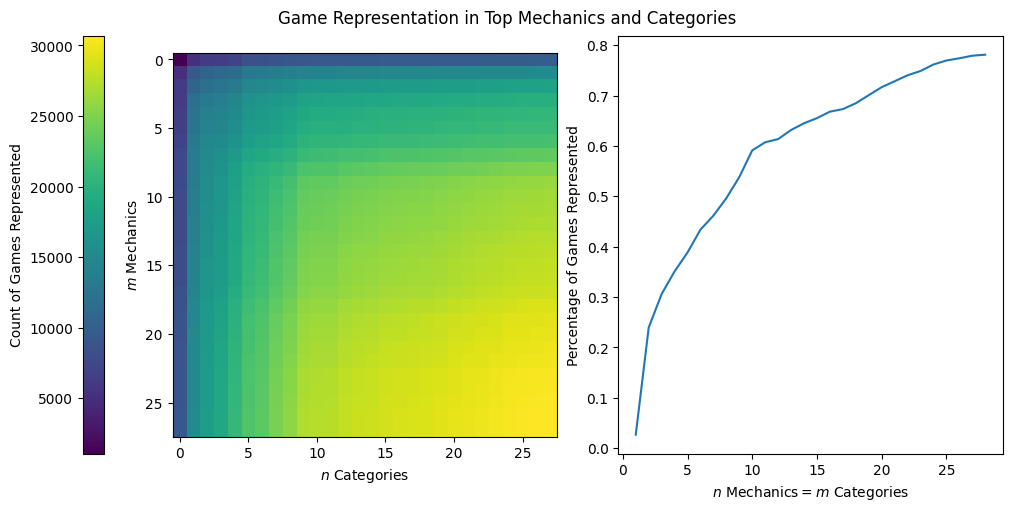

In [12]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,5), constrained_layout=True)
ax = ax.flatten()
fig.suptitle('Game Representation in Top Mechanics and Categories')


im = ax[0].imshow(mech_cat_intersect_count, aspect='auto')
ax[0].set_xlabel(r'$n$ Categories')
ax[0].set_ylabel(r'$m$ Mechanics')
colorbar = ax[0].imshow(mech_cat_intersect_count)
fig.colorbar(im, ax=ax[0], location='left', label='Count of Games Represented')

ax[1].plot(diag_pct['n'], diag_pct['pct'])
ax[1].set_xlabel(r'$n\text{ Mechanics}=m\text{ Categories}$')
ax[1].set_ylabel('Percentage of Games Represented')

fig.savefig('Figures/top_n_mechs_and_cats.png')

Keeping only the top 28 mechanics and categories (56 binary variables instead of 280) will make our results easier to interpret and compute, and reduce the risks of over-fitting while keeping approximately 75% of the games in our dataset. We should look at the success score distribution of the games we are including compared to the games we are excluding.

In [13]:
games_from_mechanics = mechanic_ordered_count[mechanic_ordered_count['top_n_mechanics'] == top_n]['games'].iloc[0]
games_from_categories = category_ordered_count[category_ordered_count['top_n_categories'] == top_n]['games'].iloc[0]
keep_games = games_from_mechanics & games_from_categories
omit_games = set(game_success[~game_success['id'].isin(keep_games)]['id'])

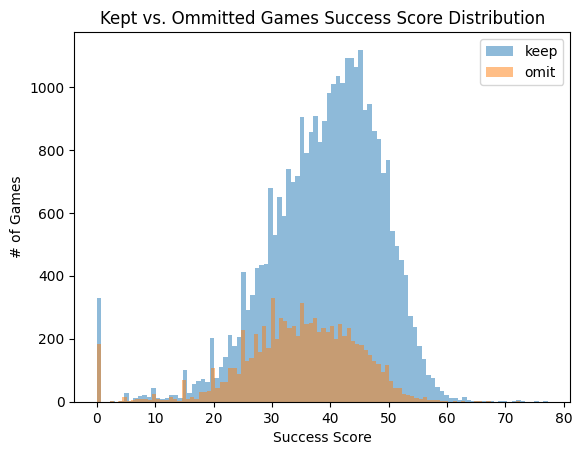

In [14]:
keep_success = game_success[game_success['id'].isin(keep_games)]
omit_success = game_success[game_success['id'].isin(omit_games)]
plt.hist(keep_success['success_score'], bins=100, alpha=0.5, label='keep')
plt.hist(omit_success['success_score'], bins=100, alpha=0.5, label='omit')
plt.legend()
plt.title('Kept vs. Ommitted Games Success Score Distribution')
plt.xlabel('Success Score')
plt.ylabel('# of Games')
plt.show()

The games being excluded follow a similar distribution, but tend to have lower success scores than the games being included. It may be worth doing a separate analysis on the more niche mechanics and categories.

## Now we will conduct our linear regression

### Define independent variables

In [15]:
mechanics_cols = list(ordered_mechanics[:top_n])
categories_cols = list(ordered_categories[:top_n])
other_cols = [
    'min_players',
    'max_players',
    'min_playtime',
    'max_playtime',
    'min_age',
    'complexity',
]

### Merge into a DataFrame to use for regression

In [16]:
regression_df = pd.merge(game_success, mechanics_binary[['id'] + mechanics_cols], on='id')
regression_df = pd.merge(regression_df, categories_binary[['id'] + categories_cols], on='id')
regression_df = regression_df[regression_df['id'].isin(keep_games)]

In [17]:
X = regression_df[other_cols + mechanics_cols + categories_cols]
y = regression_df['success_score']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f'The training dataset contains {len(X_train)} unique games.')
print(f'The testing dataset contains {len(X_test)} unique games.')

# Add intercept term
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

# Fit OLS model
model = sm.OLS(y_train, X_train)
results = model.fit()

# View regression summary
print(results.summary())

# Make predictions
y_pred_train = results.predict(X_train)
y_pred_test = results.predict(X_test)

The training dataset contains 24554 unique games.
The testing dataset contains 6139 unique games.
                            OLS Regression Results                            
Dep. Variable:          success_score   R-squared:                       0.419
Model:                            OLS   Adj. R-squared:                  0.418
Method:                 Least Squares   F-statistic:                     289.6
Date:                Fri, 12 Jun 2026   Prob (F-statistic):               0.00
Time:                        18:08:47   Log-Likelihood:                -84395.
No. Observations:               24554   AIC:                         1.689e+05
Df Residuals:                   24492   BIC:                         1.694e+05
Df Model:                          61                                         
Covariance Type:            nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
-----

In [18]:
test_errors = y_test - y_pred_test
MAE = np.mean(test_errors)
MAE

0.013754506815041395

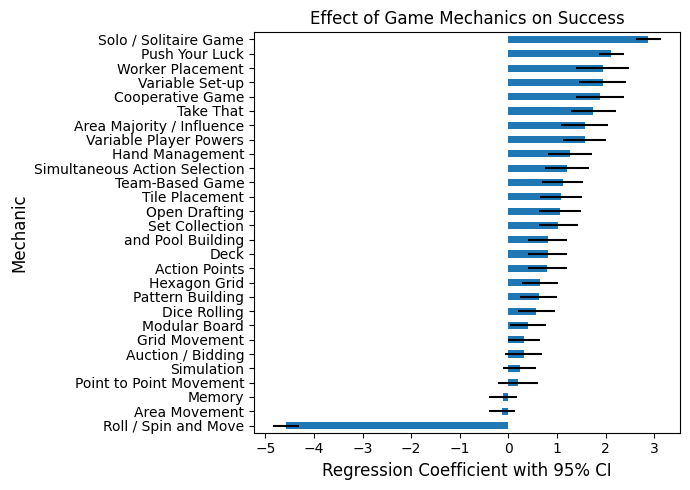

In [19]:
mech_pretty_name = {value: key for key, value in rename_mechanics.items()}

mech_coeffs = results.params[mechanics_cols].rename(mech_pretty_name)
mech_conf_ints = results.conf_int().loc[mechanics_cols].rename(mech_pretty_name)
mech_xerr = [
    mech_coeffs - mech_conf_ints[0],
    mech_conf_ints[1] - mech_coeffs
]

mech_coeffs.sort_values().plot.barh(
    figsize=(7, 5),
    xerr=mech_xerr
)

plt.title('Effect of Game Mechanics on Success')
plt.xlabel('Regression Coefficient with 95% CI', fontdict={'size':12})
plt.ylabel('Mechanic', fontdict={'size':12})
plt.tight_layout()
plt.savefig('Figures/mechanics_coeffs.jpg')

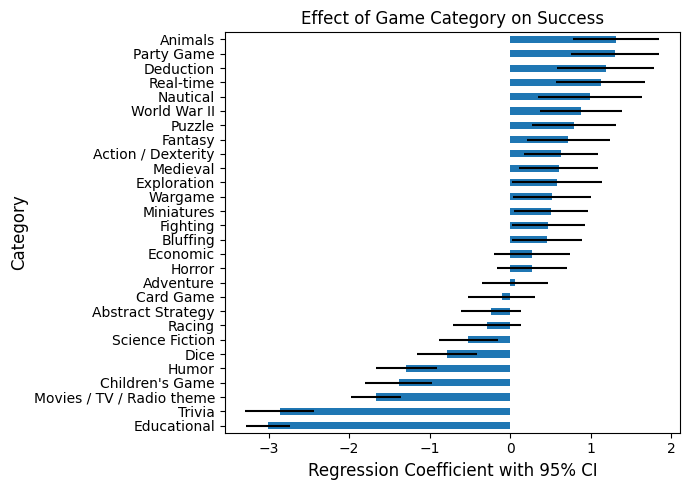

In [20]:
cat_pretty_name = {value: key for key, value in rename_categories.items()}

cat_coeffs = results.params[categories_cols].rename(cat_pretty_name)
cat_conf_ints = results.conf_int().loc[categories_cols].rename(cat_pretty_name)
cat_xerr = [
    cat_coeffs - cat_conf_ints[0],
    cat_conf_ints[1] - cat_coeffs
]

cat_coeffs.sort_values().plot.barh(
    figsize=(7, 5),
    xerr=cat_xerr
)

plt.title('Effect of Game Category on Success')
plt.xlabel('Regression Coefficient with 95% CI', fontdict={'size':12})
plt.ylabel('Category', fontdict={'size':12})
plt.tight_layout()
plt.savefig('Figures/categories_coeffs.jpg')

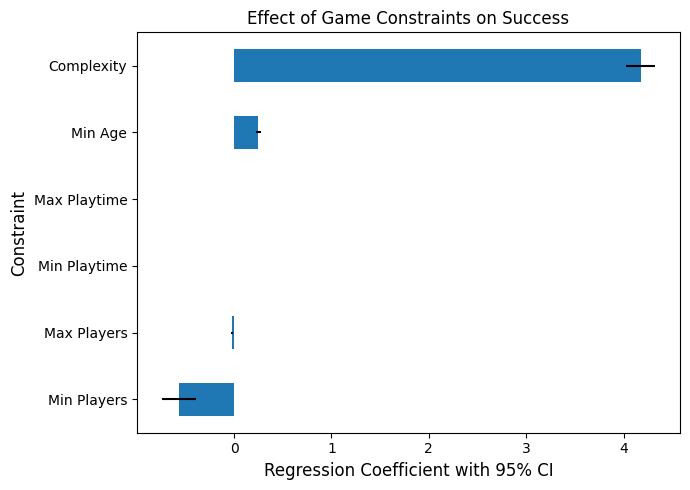

In [21]:
constraint_pretty_name = {
    'complexity': 'Complexity',
    'min_age': 'Min Age',
    'max_playtime': 'Max Playtime',
    'min_playtime': 'Min Playtime',
    'max_players': 'Max Players',
    'min_players': 'Min Players'
}

const_coeffs = results.params[other_cols].rename(constraint_pretty_name)
const_conf_ints = results.conf_int().loc[other_cols].rename(constraint_pretty_name)
const_xerr = [
    const_coeffs - const_conf_ints[0],
    const_conf_ints[1] - const_coeffs
]

const_coeffs.sort_values().plot.barh(
    figsize=(7, 5),
    xerr=const_xerr
)

plt.title('Effect of Game Constraints on Success')
plt.xlabel('Regression Coefficient with 95% CI', fontdict={'size':12})
plt.ylabel('Constraint', fontdict={'size':12})
plt.tight_layout()
plt.savefig('Figures/constraints_coeffs.jpg')

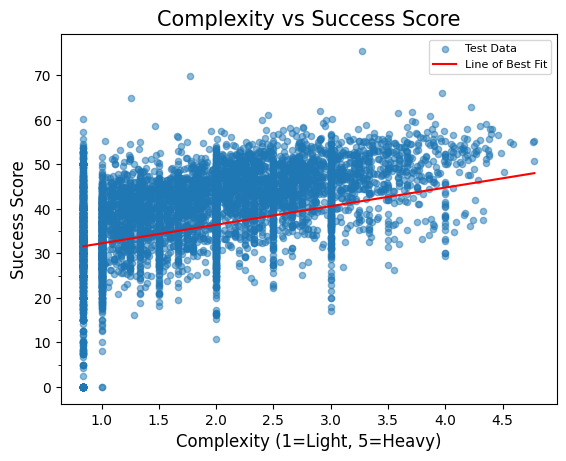

In [22]:
x_var = 'complexity'

predictions = pd.merge(left=pd.DataFrame(y_pred_test), right=regression_df, left_index=True, right_index=True)
predictions = predictions.rename(columns={0: 'y_hat'})
x = predictions[x_var]
y = predictions['success_score']
fit_x = pd.Series([predictions[x_var].min(), predictions[x_var].max()])
fit_y = results.params['const'] + fit_x * results.params[x_var]

plt.scatter(x, y, alpha=0.5, s=20)
plt.plot(fit_x, fit_y, color='red', linewidth=1.5)
plt.yticks(np.arange(0,45,5), minor=True)
plt.xticks(np.arange(1,5,0.5), minor=True)
plt.title('Complexity vs Success Score', fontdict={'size':15})
plt.xlabel('Complexity (1=Light, 5=Heavy)', fontdict={'size':12})
plt.ylabel('Success Score', fontdict={'size':12})
plt.legend(['Test Data', 'Line of Best Fit'], fontsize=8)
plt.savefig('Figures/complexity_vs_success.png')

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=b3536b60-e481-4f67-b46c-1c4de87b554b' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>